In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
# Clone the repository (shallow clone = faster)
!git clone --depth 1 https://github.com/realshubhamraut/CDAC-DBDA-coursework.git


!mkdir -p /content/data

!cp -r CDAC-DBDA-coursework/08.advanced-analytics-stats/data/* /content/data/

!ls -lh /content/data


fatal: destination path 'CDAC-DBDA-coursework' already exists and is not an empty directory.
total 548M
-rw-r--r-- 1 root root  23K Dec 13 07:44 AlgeriaFire.xlsx
-rw-r--r-- 1 root root 119K Dec 13 07:44 CDAC_DataBook.xlsx
-rw-r--r-- 1 root root 669K Dec 13 07:44 Churn_Modelling.csv
-rw-r--r-- 1 root root 8.7K Dec 13 07:44 covid_cases.xlsx
-rw-r--r-- 1 root root 159M Dec 13 07:44 credit_risk_applicants.csv
-rw-r--r-- 1 root root  28K Dec 13 07:44 credit_risk_metadata.csv
-rw-r--r-- 1 root root 387M Dec 13 07:44 credit_risk_previous_loans.csv
-rw-r--r-- 1 root root  49K Dec 13 07:44 EduData.xlsx
-rw-r--r-- 1 root root 8.9K Dec 13 07:44 ManHours.xlsx
-rw-r--r-- 1 root root 9.3K Dec 13 07:44 Marks.xlsx
-rw-r--r-- 1 root root 350K Dec 13 07:44 MetroMart.xlsx
-rw-r--r-- 1 root root 135K Dec 13 07:44 Responses.xlsx
-rw-r--r-- 1 root root 112K Dec 13 07:44 sales_data.xlsx
-rw-r--r-- 1 root root 9.2K Dec 13 07:44 SalesData.xlsx
-rw-r--r-- 1 root root 9.0K Dec 13 07:44 subject.xlsx
-rw-r--r-- 1 

In [ ]:
# Load the Excel file
df = pd.read_excel('data/EduData.xlsx')

In [ ]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
TechnicalScore       0
ExpectedSalary       0
SocialSkillsScore    0
Education            0
JobOffer             0
dtype: int64

Data types:
TechnicalScore       float64
ExpectedSalary       float64
SocialSkillsScore    float64
Education             object
JobOffer               int64
dtype: object


In [ ]:
df.head()

,TechnicalScore,ExpectedSalary,SocialSkillsScore,Education,JobOffer
0,14.413328,5.411551,62.684845,BTech,0
1,88.897319,6.890750,80.996942,BTech,1
2,93.327958,9.617579,33.757440,BTech,1
3,45.111248,6.030990,47.496977,BTech,0
4,39.435319,9.415410,14.132314,MLExpert,0


In [ ]:
edu_dummy = pd.get_dummies(df.Education, drop_first=True).astype(int)  # encode Education


In [ ]:
edu_dummy.head(10)

,MCA,MLExpert
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
5,1,0
6,1,0
7,0,0
8,1,0
9,1,0


In [ ]:
df = df.drop('Education', axis=1)  
df = pd.concat([df, edu_dummy], axis=1)  # add dummies

from sklearn.model_selection import train_test_split  # import splitter
x_train, x_test, y_train, y_test = train_test_split(df.drop('JobOffer', axis=1), df.JobOffer, test_size=0.1, random_state=20)  # train/test split

num_cols = x_train[['TechnicalScore','ExpectedSalary','SocialSkillsScore']]  # numeric train
cat_cols = x_train[['MCA','MLExpert']]  # categorical train

num_cols_test = x_test[['TechnicalScore','ExpectedSalary','SocialSkillsScore']]  # numeric test
cat_cols_test = x_test[['MCA','MLExpert']]  # categorical test

from sklearn.preprocessing import StandardScaler  # import scaler
sc = StandardScaler()  # create scaler
num_cols_tr = sc.fit_transform(num_cols)  # fit+transform train
num_cols_test_tr = sc.transform(num_cols_test)  # transform test

num_cols = pd.DataFrame(num_cols_tr, columns=num_cols.columns, index=x_train.index)  # train as DataFrame
num_cols.head()  # peek train

num_cols_test = pd.DataFrame(num_cols_test_tr, columns=num_cols_test.columns, index=x_test.index)  # test as DataFrame
num_cols_test.head()  # peek test

x_train = pd.concat([num_cols, cat_cols], axis=1)  # final X train
x_test = pd.concat([num_cols_test, cat_cols_test], axis=1)  # final X test

x_train.head()  # peek final train

KeyError: "['Education'] not found in axis"

In [ ]:
import tensorflow
from tensorflow.keras.models import Sequential # helps with the forward and backward propagation
from tensorflow.keras.layers import Dense # this is for the hidden, input and output layers
from tensorflow.keras.layers import LeakyReLU,ReLU # activation functions
from tensorflow.keras.layers import Dropout

In [ ]:
classifier = Sequential()
classifier.add(Dense(units=5,activation='relu')) #  input layer
classifier.add(Dense(units=7,activation='relu')) #  input first hidden layer
classifier.add(Dense(units=6,activation='relu')) #  input second hidden layer
classifier.add(Dense(units=1, activation='sigmoid'))  # output layer

In [ ]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
x_train.shape

(630, 5)

In [ ]:
mod1 = classifier.fit(x_train, y_train, epochs=30, batch_size=10)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8163 - loss: 0.4187
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8163 - loss: 0.4187
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8338 - loss: 0.4046
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8338 - loss: 0.4046
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8324 - loss: 0.3997
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8324 - loss: 0.3997
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.4202
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.4202
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8436 - loss: 0.3934
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8436 - loss: 0.3934
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.4139
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss:

In [ ]:
y_pred = classifier.predict(x_test)
y_pred = (y_pred>0.5).astype(int)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[35, 13],
       [ 6, 16]])

In [ ]:
import tensorflow as tf
import torch

In [ ]:
sc1 = tf.constant(10)

In [ ]:
sc1.dtype

tf.int32

In [ ]:
sc1.numpy().item()

10

In [ ]:
v1 = tf.constant((1,2,3))

In [ ]:
v1

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [ ]:
v2 = tf.constant([[1,2,3], [4,5,6]])

In [ ]:
v2

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [ ]:
arr1 = np.array(v2)
t2 = tf.convert_to_tensor(arr1)


In [ ]:
arr1[0][2] = 100

In [ ]:
arr1

array([[  1,   2, 100],
       [  4,   5,   6]], dtype=int32)

In [ ]:
t3 = tf.random.uniform(shape=(2,3), minval=0, maxval=10)

In [ ]:
t3

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[4.187026 , 8.003186 , 2.7094257],
       [1.6316593, 1.7879868, 5.5820265]], dtype=float32)>

In [ ]:
# Generate a 2x3 array of normal random values (mean=20, stddev=5)
t4 = tf.random.normal(shape=(2,3), mean=20, stddev=5)

In [ ]:
t4

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[21.150314, 23.97742 , 18.432295],
       [27.644222, 25.87705 , 25.558949]], dtype=float32)>

In [ ]:
d = t4.numpy().flatten()

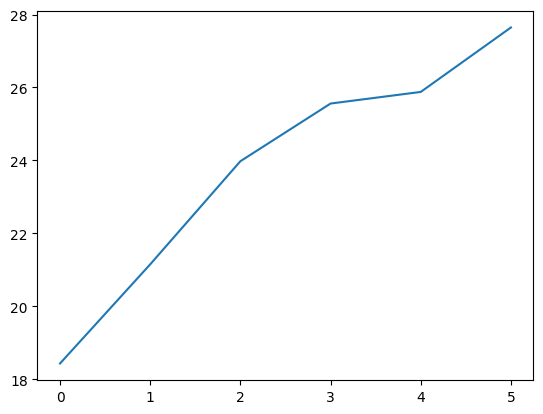

In [ ]:
plt.plot(sorted(d))
plt.show()

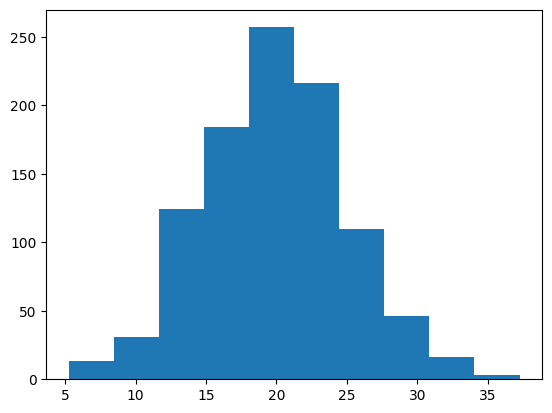

In [ ]:
t4 = tf.random.normal(shape=(1000,), mean=20, stddev=5)
d = t4.numpy()
plt.hist(sorted(d))
plt.show()

In [6]:
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2 + 3*x
    grad = tape.gradient(y,x)
    print(grad)


NameError: name 'tf' is not defined